In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadwaqasms/lateblighttomatodisease")

print("Path to dataset files:", path)

100%|██████████| 97.3M/97.3M [00:00<00:00, 224MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadwaqasms/lateblighttomatodisease/versions/2


Using device: cuda
Training samples: 844
Validation samples: 356


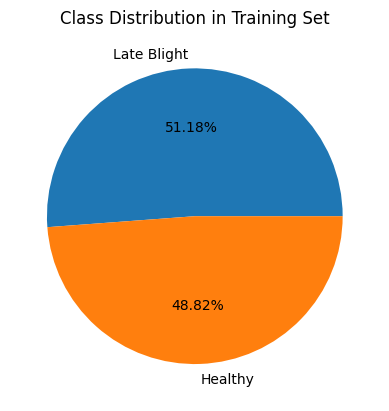

Train batches: 53
Validation batches: 20
Test batches: 3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 172MB/s]



Starting Training...
Epoch  1/20 | Train Loss: 0.7129 | Val Loss: 0.7056 | Val Acc: 0.6781 | Time: 34.61s
Epoch  2/20 | Train Loss: 0.4987 | Val Loss: 0.2257 | Val Acc: 0.9156 | Time: 34.90s
Epoch  3/20 | Train Loss: 0.3224 | Val Loss: 0.1616 | Val Acc: 0.9313 | Time: 36.93s
Epoch  4/20 | Train Loss: 0.1976 | Val Loss: 0.0894 | Val Acc: 0.9594 | Time: 39.96s
Epoch  5/20 | Train Loss: 0.2025 | Val Loss: 0.0689 | Val Acc: 0.9656 | Time: 39.11s
Epoch  6/20 | Train Loss: 0.0887 | Val Loss: 0.0673 | Val Acc: 0.9688 | Time: 39.20s
Epoch  7/20 | Train Loss: 0.0721 | Val Loss: 0.0545 | Val Acc: 0.9875 | Time: 39.48s
Epoch  8/20 | Train Loss: 0.0649 | Val Loss: 0.0351 | Val Acc: 0.9875 | Time: 39.02s
Epoch  9/20 | Train Loss: 0.0407 | Val Loss: 0.0202 | Val Acc: 0.9938 | Time: 39.19s
Epoch 10/20 | Train Loss: 0.0384 | Val Loss: 0.0226 | Val Acc: 0.9938 | Time: 39.29s
Epoch 11/20 | Train Loss: 0.0271 | Val Loss: 0.0181 | Val Acc: 0.9969 | Time: 39.12s
Epoch 12/20 | Train Loss: 0.0289 | Val Loss

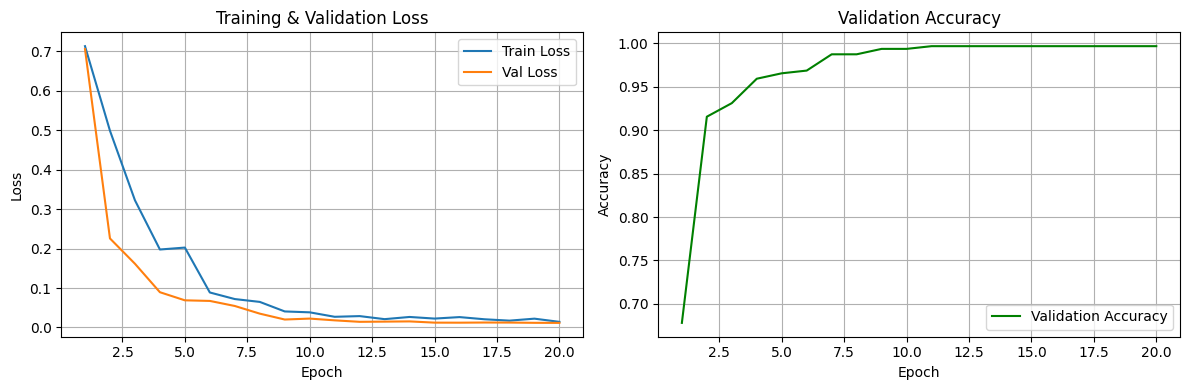


Testing on Unseen Data...
Test Loss: 0.0067
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

 Late Blight       1.00      1.00      1.00        17
     Healthy       1.00      1.00      1.00        19

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Confusion Matrix:
[[17  0]
 [ 0 19]]


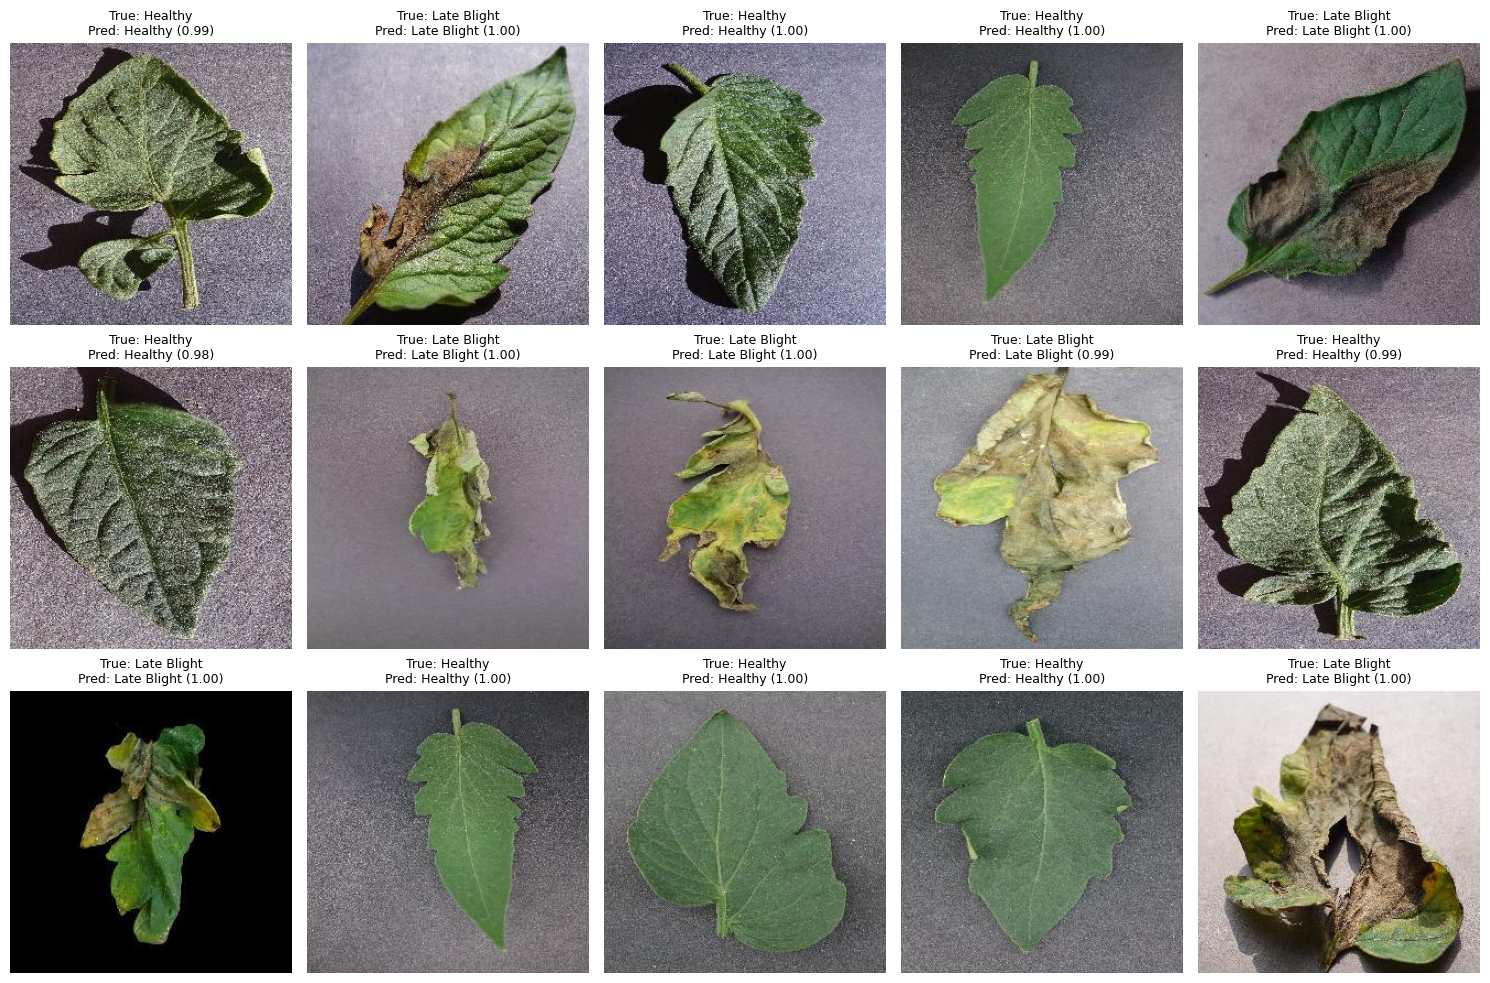


Best model saved as 'vit_b16_late_blight.pth'


In [ ]:
# ============================================
# 1. Import Required Libraries
# ============================================
import numpy as np
import pandas as pd
import os
import time
from copy import deepcopy

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import vit_b_16

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================
# Colab Data Setup Instructions
# ============================================
# If you are running this in Google Colab, you need to ensure the 'Tomato_Dataset' is available.
# Common steps:
# 1. Upload 'Tomato_Dataset.zip' to your Colab session (File browser on the left).
# 2. Uncomment and run the following lines to unzip the dataset.
#    Make sure the unzipped folder is named 'Tomato_Dataset'.

# import zipfile
# zip_file_path = 'Tomato_Dataset.zip'
# dataset_extract_path = 'Tomato_Dataset'
# if os.path.exists(zip_file_path) and not os.path.exists(dataset_extract_path):
#     print(f"Unzipping '{zip_file_path}'...")
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         zip_ref.extractall('.')
#     print(f"'{zip_file_path}' unzipped to '{dataset_extract_path}'.")
# elif not os.path.exists(zip_file_path):
#     print(f"Warning: '{zip_file_path}' not found. Please upload the dataset zip file.")
# else:
#     print(f"'{dataset_extract_path}' already exists or '{zip_file_path}' not present to unzip.")

# ============================================
# 2. Configuration Parameters
# ============================================
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 0.001
STEP_SIZE = 5
GAMMA = 0.1
IMG_SIZE = 224
NUM_CLASSES = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# ============================================
# 3. Dataset Creation Function
# ============================================
def create_dataset(path, train=True):
    """
    Create a DataFrame containing image paths and labels.
    """
    subset = 'train' if train else 'valid'
    full_path = os.path.join(path, subset)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Dataset path not found: {full_path}. Please ensure the dataset is correctly placed.")

    # Late blight images
    blight_path = os.path.join(full_path, "Tomato___Late_blight")
    blight_files = [f for f in os.listdir(blight_path) if f.endswith(('.jpg', '.JPG'))]
    blight_images = [os.path.join(blight_path, f) for f in blight_files]
    blight_labels = [0] * len(blight_images)  # 0 = Late Blight

    # Healthy images
    healthy_path = os.path.join(full_path, "Tomato___healthy")
    healthy_files = [f for f in os.listdir(healthy_path) if f.endswith(('.jpg', '.JPG'))]
    healthy_images = [os.path.join(healthy_path, f) for f in healthy_files]
    healthy_labels = [1] * len(healthy_images)  # 1 = Healthy

    # Combine
    all_images = blight_images + healthy_images
    all_labels = blight_labels + healthy_labels

    df = pd.DataFrame({'images': all_images, 'label': all_labels})
    return df

# ============================================
# 4. Data Loading
# ============================================
path = "/root/.cache/kagglehub/datasets/muhammadwaqasms/lateblighttomatodisease/versions/2" # Explicitly define path
dataset_path = os.path.join(path, "Tomato_Dataset") # Updated path to include 'Tomato_Dataset' subfolder

train_df = create_dataset(dataset_path, train=True)
valid_df = create_dataset(dataset_path, train=False)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")

# Visualize class distribution
label_counts = train_df['label'].value_counts()
plt.pie(label_counts, labels=['Late Blight', 'Healthy'], autopct='%0.2f%%')
plt.title("Class Distribution in Training Set")
plt.show()

# ============================================
# 5. Data Augmentation & Preprocessing
# ============================================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ============================================
# 6. Custom Dataset Class
# ============================================
class TomatoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.values
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = np.asarray(Image.open(img_path).convert('RGB'))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# ============================================
# 7. Split Validation into Val and Test
# ============================================
val_df, test_df = train_test_split(valid_df, test_size=0.1, random_state=42)

# Create datasets
train_dataset = TomatoDataset(train_df, transform=train_transform)
val_dataset = TomatoDataset(val_df, transform=val_transform)
test_dataset = TomatoDataset(test_df, transform=val_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================================
# 8. ViT-B16 Model Definition
# ============================================
def create_vit_model(num_classes=NUM_CLASSES):
    """
    Create a Vision Transformer (ViT-B/16) model pretrained on ImageNet-21k.
    """
    model = vit_b_16(weights="IMAGENET1K_V1")

    # Replace the classifier head for binary classification
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)

    return model.to(DEVICE)

model = create_vit_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

# ============================================
# 9. Training Function
# ============================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    return epoch_loss

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    accuracy = accuracy_score(all_labels, all_preds)
    return epoch_loss, accuracy, all_preds, all_labels

# ============================================
# 10. Training Loop
# ============================================
best_model = deepcopy(model)
best_accuracy = 0.0

train_losses = []
val_losses = []
val_accuracies = []

print("\n" + "="*60)
print("Starting Training...")
print("="*60)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model = deepcopy(model)

    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.2f}s")

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time:.2f} seconds")
print(f"Best validation accuracy: {best_accuracy:.4f}")

# ============================================
# 11. Plot Training Curves
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss')
axes[0].plot(range(1, EPOCHS+1), val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================
# 12. Evaluation on Test Set
# ============================================
print("\n" + "="*60)
print("Testing on Unseen Data...")
print("="*60)

test_loss, test_accuracy, test_preds, test_labels = validate(best_model, test_loader, criterion, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Late Blight', 'Healthy']))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)

# ============================================
# 13. Prediction Function
# ============================================
def predict_image(image_path, model, transform, device):
    """
    Predict class for a single image.
    """
    image = Image.open(image_path).convert('RGB')
    image = np.asarray(image)
    image = transform(image)
    image = image.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        prediction = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1).max().item()

    return prediction, confidence

# ============================================
# 14. Visualize Predictions on Test Samples
# ============================================
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i in range(min(15, len(test_df))):
    img_path = test_df.iloc[i, 0]
    true_label = test_df.iloc[i, 1]
    pred_label, confidence = predict_image(img_path, best_model, val_transform, DEVICE)

    class_names = ['Late Blight', 'Healthy']
    title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})"

    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 15. Save Best Model (Optional)
# ============================================
torch.save(best_model.state_dict(), "vit_b16_late_blight.pth")
print("\nBest model saved as 'vit_b16_late_blight.pth'")


Confusion Matrix:
[[17  0]
 [ 0 19]]


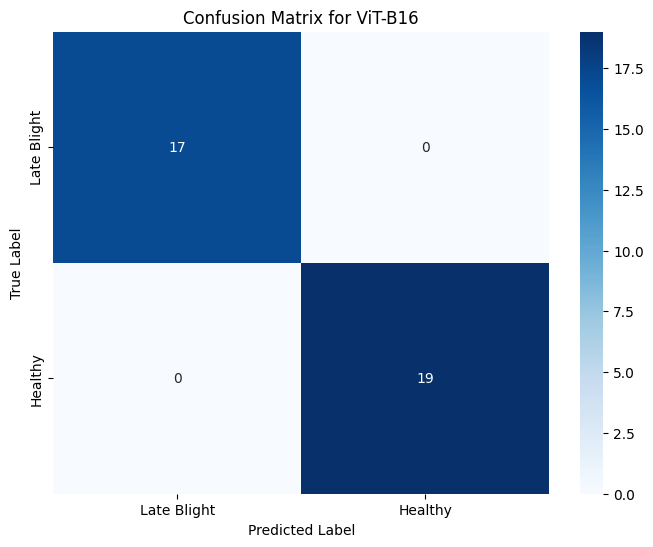


Classification Report:
              precision    recall  f1-score   support

 Late Blight       1.00      1.00      1.00        17
     Healthy       1.00      1.00      1.00        19

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming test_labels and test_preds are available from the previous execution

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Late Blight', 'Healthy'],
            yticklabels=['Late Blight', 'Healthy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ViT-B16')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Late Blight', 'Healthy']))

In [ ]:
print('Rerunning the main training and evaluation cell (JhXbwMlSIF76) to define test_labels and test_preds.')
# You would typically re-execute cell JhXbwMlSIF76 here if not already executed manually.

Rerunning the main training and evaluation cell (JhXbwMlSIF76) to define test_labels and test_preds.


In [ ]:
import os

zip_file_name = 'Tomato_Dataset.zip' # Or whatever your zip file is named

if os.path.exists(zip_file_name):
    print(f"The file '{zip_file_name}' exists in the current directory.")
else:
    print(f"The file '{zip_file_name}' does NOT exist in the current directory.")


The file 'Tomato_Dataset.zip' does NOT exist in the current directory.
